### 모델 학습 및 검증 과정 요약

> ① 모델 선정
>
> * **선형 계열**: Linear Regression, Ridge, Lasso, ElasticNet
> * **트리 계열**: RandomForest, GradientBoosting
> * **부스팅 계열**: XGBoost, LightGBM, CatBoost
> * **선정 이유**: 단순 선형부터 최신 앙상블까지 다양한 알고리즘 비교를 통해 최적 모델 탐색

<br>

> ② 교차검증 및 하이퍼파라미터 튜닝
>
> * **교차검증 방식**: 시계열 특성을 반영한 **TimeSeriesSplit**
> * **최적화 방법**: GridSearchCV를 활용하여 주요 하이퍼파라미터 탐색
> * **평가지표**: RMSE(중점), MAE, R²

<br>

> ③ 성능 평가
>
> * **홀드아웃 검증**: 훈련/테스트 데이터 분리 후 성능 검증
> * **Baseline 비교**: Persistence(전일값 유지)와 단순 평균 대비 개선율(스킬 스코어) 산출
> * **깊이별 결과**: 10, 20, 60cm에서 R² 약 0.75\~0.83로 안정적, 40cm는 센서 고장/보간으로 성능 저하

<br>

> ④ 모델 해석 및 검증
>
> * **Feature Importance**: Permutation Importance, SHAP 분석으로 변수 기여도 확인
> * **Ablation Study**: 기압 변수 제거 시 성능 붕괴 → 기압의 핵심적 역할 검증
> * **잔차 분석**: 저수분/고수분 구간별 예측 편향 확인

<br>

> ⑤ 종합 결론
>
> * **최적 모델**: XGBoost, LightGBM, CatBoost 등 부스팅 계열이 가장 안정적 성능 확보
> * **의의**: 기압·강수량·바람 등 주요 기상 변수가 토양 수분 예측에 결정적 기여
> * **한계**: 센서 이상·보간 데이터 구간에서 성능 저하 및 데이터셋 자체의 크기가 다소 부족 --> 추가 테스트 과정에서 데이터 추가 수집 및 검증 필요


In [1]:
#설치 필요
!pip install -q numpy pandas scikit-learn xgboost lightgbm catboost scikeras tensorflow matplotlib

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [2]:
import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple

from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


try:
    from scikeras.wrappers import KerasRegressor
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except Exception as e:
    KerasRegressor = None
    tf = None
    keras = None
    layers = None

np.random.seed(42)
pd.set_option('display.max_columns', 120)


In [1]:
from google.colab import drive
import pandas as pd

# Google Drive 마운트
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# CSV 불러오기
df = pd.read_csv("merged_data.csv")

print(df.head())

           일자  10센티미터(cm)  20센티미터(cm)  40센티미터(cm)  60센티미터(cm) 측정지점         위도  \
0  2024-01-01        43.4        50.1        37.6        46.6   안천  35.869421   
1  2024-01-02        42.6        49.9        38.6        46.7   안천  35.869421   
2  2024-01-03        42.4        49.6        38.7        46.7   안천  35.869421   
3  2024-01-04        42.3        49.6        38.6        46.7   안천  35.869421   
4  2024-01-05        41.8        49.4        38.4        46.7   안천  35.869421   

           경도  기온_DYTM_TMX  기온_MRNG_TMN  기온_NGHT_TMN  기온_TA_DAVG  기온_TMN_DD  \
0  127.543329          7.2         -1.6          1.1         2.7       -1.6   
1  127.543329          4.9          1.1         -0.3         2.6        1.1   
2  127.543329          3.3         -0.3         -6.2         0.8       -1.8   
3  127.543329          5.3         -6.2         -4.2        -1.2       -6.2   
4  127.543329          6.6         -4.2         -3.1         3.5       -4.2   

   기온_TMX_DD  강수량_RN_DSUM  강수량_RN_MAX_

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2196 entries, 0 to 2195
Data columns (total 53 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   일자               2196 non-null   object 
 1   10센티미터(cm)       2196 non-null   float64
 2   20센티미터(cm)       2196 non-null   float64
 3   40센티미터(cm)       2196 non-null   float64
 4   60센티미터(cm)       2196 non-null   float64
 5   측정지점             2196 non-null   object 
 6   위도               2196 non-null   float64
 7   경도               2196 non-null   float64
 8   기온_DYTM_TMX      2196 non-null   float64
 9   기온_MRNG_TMN      2196 non-null   float64
 10  기온_NGHT_TMN      2196 non-null   float64
 11  기온_TA_DAVG       2196 non-null   float64
 12  기온_TMN_DD        2196 non-null   float64
 13  기온_TMX_DD        2196 non-null   float64
 14  강수량_RN_DSUM      2196 non-null   float64
 15  강수량_RN_MAX_10M   2196 non-null   float64
 16  강수량_RN_MAX_1HR   2196 non-null   float64
 17  강수량_RN_MAX_6HR

In [6]:
corr = df[["10센티미터(cm)", "20센티미터(cm)", "40센티미터(cm)", "60센티미터(cm)"]].corr()
corr

,10센티미터(cm),20센티미터(cm),40센티미터(cm),60센티미터(cm)
10센티미터(cm),1.000000,0.932658,0.901842,0.893512
20센티미터(cm),0.932658,1.000000,0.913826,0.941550
40센티미터(cm),0.901842,0.913826,1.000000,0.895306
60센티미터(cm),0.893512,0.941550,0.895306,1.000000


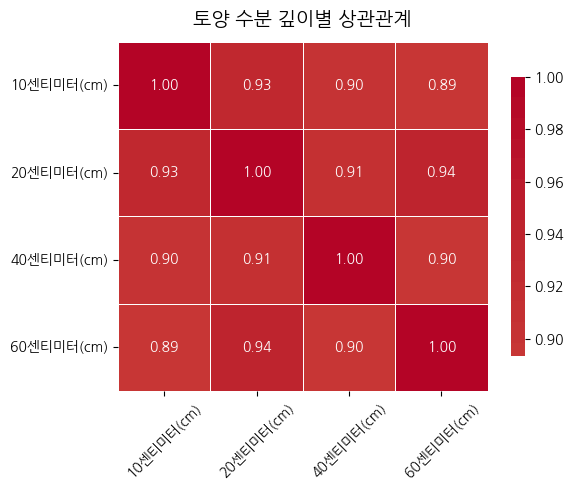

In [8]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 나눔고딕 폰트 적용
plt.rc('font', family='NanumGothic')

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f",
            linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title("토양 수분 깊이별 상관관계", fontsize=14, pad=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
df['일자'] = pd.to_datetime(df['일자'])
df = df.sort_values('일자').reset_index(drop=True)

In [10]:
df.head()

,일자,10센티미터(cm),20센티미터(cm),40센티미터(cm),60센티미터(cm),측정지점,위도,경도,기온_DYTM_TMX,기온_MRNG_TMN,기온_NGHT_TMN,기온_TA_DAVG,기온_TMN_DD,기온_TMX_DD,강수량_RN_DSUM,강수량_RN_MAX_10M,강수량_RN_MAX_1HR,강수량_RN_MAX_6HR,기압_PA_MAVG,기압_PA_MAX,기압_PA_MIN,기압_PS_MAX,바람_WD_FRQ,바람_WD_INS_MAX,바람_WD_MAX,바람_WD_MIX,바람_WS_DAVG,바람_WS_INS_MAX,바람_WS_MAX,바람_WS_MIX,이슬점온도_TD_AVG,이슬점온도_TD_MAX,이슬점온도_TD_MIN,초상온도_TG_MIN,습도_RHM_AVG,습도_RHM_MIN,증기압_PV_DAVG,증기압_PV_MAX,증기압_PV_MIN,구름_CA_MAX,구름_LMAC_DAVG,구름_TCA_DAVG,시정_VS_MIN,적설_FSD_DMAX,적설_SD_DMAX,일사_GSR_DSUM,일사_SI_HR1_MAX,일조_SSRATE,일조_SS_HR_DSUM,증발량_LRG_EV_DSUM,증발량_SML_EV_DSUM,황사_PM10_DAVG,안개_FOG_DUR_DSUM
0,2024-01-01,43.4,50.1,37.6,46.6,안천,35.869421,127.543329,7.2,-1.6,1.1,2.7,-1.6,7.2,0.0,0.0,0.0,42.5,991.6,993.95,990.0,1030.4,225.0,222.2,212.9,199.7,1.1,4.5,3.2,0.0,0.7,2.1,-1.0,-5.1,83.0,57.6,6.5,7.1,5.7,10.0,4.0,5.1,16,0.0,0.0,8.0,1.7,24.5,2.4,1.1,1.5,21.0,0.0
1,2024-01-01,22.9,25.1,21.9,19.1,부귀,35.862286,127.399247,7.2,-1.6,1.1,2.7,-1.6,7.2,0.0,0.0,0.0,42.5,915.1,917.10,913.4,1031.9,225.0,222.2,212.9,199.7,1.1,4.5,3.2,0.0,0.7,1.6,-0.3,-4.3,83.0,57.6,6.4,6.9,6.0,9.0,4.0,4.4,307,0.0,0.0,8.0,1.7,65.3,6.4,1.1,1.5,21.0,0.0
2,2024-01-01,35.2,30.5,26.9,29.5,계북,35.808002,127.628078,-1.1,-7.0,-5.6,-4.2,-7.0,-1.1,0.0,0.0,0.0,69.5,852.8,854.60,850.8,1033.2,202.5,191.0,212.9,199.7,1.1,8.1,3.2,0.0,-0.4,1.0,-1.6,-4.3,98.0,94.5,5.9,6.6,5.4,9.0,1.0,2.0,15,0.0,0.0,8.0,1.7,34.7,3.4,1.1,1.5,21.0,0.0
3,2024-01-01,36.7,35.0,34.2,33.2,상전,35.805430,127.484713,7.5,-1.5,1.9,2.7,-1.5,7.5,0.0,0.0,0.0,0.0,977.4,979.60,976.0,1030.6,230.0,270.0,270.0,217.7,0.8,6.2,3.8,0.0,0.7,1.6,-0.3,-4.3,82.1,53.0,6.4,6.9,6.0,9.0,4.0,4.4,307,0.0,0.0,8.0,1.7,65.3,6.4,1.1,1.5,21.0,0.0
4,2024-01-01,31.2,29.9,29.2,30.3,주천,35.970598,127.423981,7.3,-1.0,2.3,2.7,-1.0,7.3,0.0,0.0,0.0,0.0,1005.8,1008.30,1004.0,1030.2,270.0,360.0,340.0,288.8,0.6,3.6,1.7,0.0,0.7,1.6,-0.3,-5.9,87.8,62.0,6.4,6.9,6.0,9.0,4.0,4.4,307,0.0,0.0,8.0,1.7,65.3,6.4,1.1,1.5,21.0,0.0


In [11]:
targets = ["10센티미터(cm)", "20센티미터(cm)", "40센티미터(cm)", "60센티미터(cm)"]
df["target_avg"] = df[targets].mean(axis=1)

X = df.drop(columns=["일자","측정지점","위도","경도"] + targets + ["target_avg"])
y_dict = {t: df[t] for t in targets}
y_dict["target_avg"] = df["target_avg"]


In [12]:
X

,기온_DYTM_TMX,기온_MRNG_TMN,기온_NGHT_TMN,기온_TA_DAVG,기온_TMN_DD,기온_TMX_DD,강수량_RN_DSUM,강수량_RN_MAX_10M,강수량_RN_MAX_1HR,강수량_RN_MAX_6HR,기압_PA_MAVG,기압_PA_MAX,기압_PA_MIN,기압_PS_MAX,바람_WD_FRQ,바람_WD_INS_MAX,바람_WD_MAX,바람_WD_MIX,바람_WS_DAVG,바람_WS_INS_MAX,바람_WS_MAX,바람_WS_MIX,이슬점온도_TD_AVG,이슬점온도_TD_MAX,이슬점온도_TD_MIN,초상온도_TG_MIN,습도_RHM_AVG,습도_RHM_MIN,증기압_PV_DAVG,증기압_PV_MAX,증기압_PV_MIN,구름_CA_MAX,구름_LMAC_DAVG,구름_TCA_DAVG,시정_VS_MIN,적설_FSD_DMAX,적설_SD_DMAX,일사_GSR_DSUM,일사_SI_HR1_MAX,일조_SSRATE,일조_SS_HR_DSUM,증발량_LRG_EV_DSUM,증발량_SML_EV_DSUM,황사_PM10_DAVG,안개_FOG_DUR_DSUM
0,7.2,-1.6,1.1,2.7,-1.6,7.2,0.0,0.0,0.0,42.5,991.60,993.95,990.00,1030.40,225.0,222.2,212.9,199.7,1.1,4.5,3.2,0.0,0.7,2.1,-1.0,-5.10,83.0,57.6,6.5,7.1,5.7,10.0,4.0,5.1,16,0.0,0.0,8.0,1.7,24.5,2.4,1.1,1.5,21.0,0.0
1,7.2,-1.6,1.1,2.7,-1.6,7.2,0.0,0.0,0.0,42.5,915.10,917.10,913.40,1031.90,225.0,222.2,212.9,199.7,1.1,4.5,3.2,0.0,0.7,1.6,-0.3,-4.30,83.0,57.6,6.4,6.9,6.0,9.0,4.0,4.4,307,0.0,0.0,8.0,1.7,65.3,6.4,1.1,1.5,21.0,0.0
2,-1.1,-7.0,-5.6,-4.2,-7.0,-1.1,0.0,0.0,0.0,69.5,852.80,854.60,850.80,1033.20,202.5,191.0,212.9,199.7,1.1,8.1,3.2,0.0,-0.4,1.0,-1.6,-4.30,98.0,94.5,5.9,6.6,5.4,9.0,1.0,2.0,15,0.0,0.0,8.0,1.7,34.7,3.4,1.1,1.5,21.0,0.0
3,7.5,-1.5,1.9,2.7,-1.5,7.5,0.0,0.0,0.0,0.0,977.40,979.60,976.00,1030.60,230.0,270.0,270.0,217.7,0.8,6.2,3.8,0.0,0.7,1.6,-0.3,-4.30,82.1,53.0,6.4,6.9,6.0,9.0,4.0,4.4,307,0.0,0.0,8.0,1.7,65.3,6.4,1.1,1.5,21.0,0.0
4,7.3,-1.0,2.3,2.7,-1.0,7.3,0.0,0.0,0.0,0.0,1005.80,1008.30,1004.00,1030.20,270.0,360.0,340.0,288.8,0.6,3.6,1.7,0.0,0.7,1.6,-0.3,-5.90,87.8,62.0,6.4,6.9,6.0,9.0,4.0,4.4,307,0.0,0.0,8.0,1.7,65.3,6.4,1.1,1.5,21.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2191,3.5,-2.2,-7.5,-4.1,-5.0,4.2,0.5,0.5,0.5,3.0,906.95,909.10,903.75,1025.40,247.5,250.3,244.3,233.8,2.3,7.4,5.1,1.0,-5.3,2.9,-9.3,-8.65,61.0,27.6,4.2,7.5,3.0,10.0,0.0,0.9,700,0.0,0.0,11.0,1.9,91.8,9.0,1.5,2.2,34.0,0.0
2192,-6.1,-10.6,-11.9,-8.1,-11.3,-3.1,0.5,0.5,0.5,3.0,842.60,844.50,840.00,1025.40,292.5,322.0,308.0,293.4,5.5,17.2,9.1,5.0,-7.6,0.4,-13.6,-8.65,81.0,52.7,3.5,6.3,2.1,10.0,0.0,0.9,1122,0.0,0.0,8.0,1.5,82.7,8.1,1.3,1.9,34.0,0.0
2193,3.5,-2.2,-7.5,0.8,-5.0,4.2,0.5,0.5,0.5,3.0,985.55,988.40,981.40,1025.35,247.5,250.3,244.3,233.8,2.3,7.4,5.1,1.0,-7.7,1.8,-11.5,-12.30,61.0,27.6,3.6,7.0,2.5,10.0,0.0,0.9,1040,0.0,0.0,11.0,1.9,91.8,9.0,1.5,2.2,34.0,0.0
2194,3.7,-0.4,-7.6,-0.1,-6.4,5.0,0.0,0.0,0.0,0.0,971.30,973.70,967.50,1025.40,320.0,320.0,320.0,335.2,2.3,11.5,5.4,2.0,-5.3,2.9,-9.3,-11.40,59.6,27.0,4.2,7.5,3.0,10.0,0.0,0.9,700,0.0,0.0,11.0,1.9,91.8,9.0,1.5,2.2,34.0,0.0


In [13]:
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train_dict = {k: v.iloc[:split_idx] for k,v in y_dict.items()}
y_test_dict  = {k: v.iloc[split_idx:] for k,v in y_dict.items()}


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

num_cols = X_train.select_dtypes(include=["float64","int64"]).columns
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols)
])


In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = Pipeline([
    ("prep", preprocessor),
    ("rf", RandomForestRegressor(n_estimators=300, random_state=42))
])

rows = []

for tgt in targets + ["target_avg"]:
    model.fit(X_train, y_train_dict[tgt])
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test_dict[tgt], preds)
    mse = mean_squared_error(y_test_dict[tgt], preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_dict[tgt], preds)
    rows.append({
        "Target": tgt,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })
    print(f"{tgt} → MAE: {mae:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}")


10센티미터(cm) → MAE: 2.715, RMSE: 3.366, R2: 0.749
20센티미터(cm) → MAE: 2.995, RMSE: 3.713, R2: 0.806
40센티미터(cm) → MAE: 3.545, RMSE: 4.503, R2: 0.550
60센티미터(cm) → MAE: 2.954, RMSE: 4.027, R2: 0.825
target_avg → MAE: 2.854, RMSE: 3.565, R2: 0.782


,MAE,RMSE,R2
Target,,,
10센티미터(cm),2.715,3.366,0.749
20센티미터(cm),2.995,3.713,0.806
40센티미터(cm),3.545,4.503,0.550
60센티미터(cm),2.954,4.027,0.825
target_avg,2.854,3.565,0.782


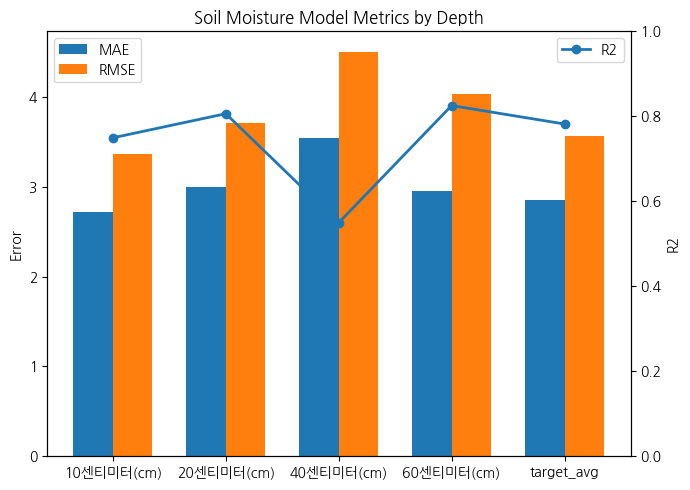

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df_scores = pd.DataFrame(rows).set_index("Target").sort_index()
display(df_scores.style.format({"MAE":"{:.3f}","RMSE":"{:.3f}","R2":"{:.3f}"})
        .bar(subset=["R2"], color="#a6cee3")
        .background_gradient(cmap="Greys", subset=["MAE","RMSE"], vmin=df_scores[["MAE","RMSE"]].min().min(),
                             vmax=df_scores[["MAE","RMSE"]].max().max())
       )


fig, ax1 = plt.subplots(figsize=(7,5))

x = np.arange(len(df_scores))
width = 0.35

# MAE/RMSE
ax1.bar(x - width/2, df_scores["MAE"], width, label="MAE")
ax1.bar(x + width/2, df_scores["RMSE"], width, label="RMSE")
ax1.set_ylabel("Error")
ax1.set_xticks(x)
ax1.set_xticklabels(df_scores.index)
ax1.legend(loc="upper left")

# R2
ax2 = ax1.twinx()
ax2.plot(x, df_scores["R2"], marker="o", linewidth=2, label="R2")
ax2.set_ylim(0, 1)
ax2.set_ylabel("R2")

# 범례
lines, labels = ax2.get_legend_handles_labels()
ax2.legend(lines, labels, loc="upper right")

plt.title("Soil Moisture Model Metrics by Depth")
plt.tight_layout()
plt.show()


학습 파일로 스킵 가능

In [ ]:
import math, warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import GridSearchCV, KFold, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    xgb_available = True
except Exception:
    xgb_available = False

try:
    from lightgbm import LGBMRegressor
    lgb_available = True
except Exception:
    lgb_available = False

try:
    from catboost import CatBoostRegressor
    cb_available = True
except Exception:
    cb_available = False


cv = TimeSeriesSplit(n_splits=3)

models_and_grids = []

# 선형 계열
models_and_grids.append((
    "LinearRegression",
    Pipeline([("prep", preprocessor), ("model", LinearRegression())]),
    {"model__fit_intercept": [True, False]}
))

models_and_grids.append((
    "Ridge",
    Pipeline([("prep", preprocessor), ("model", Ridge(random_state=42))]),
    {"model__alpha": [0.1, 1.0, 10.0, 100.0]}
))

models_and_grids.append((
    "Lasso",
    Pipeline([("prep", preprocessor), ("model", Lasso(random_state=42, max_iter=10000))]),
    {"model__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0]}
))

models_and_grids.append((
    "ElasticNet",
    Pipeline([("prep", preprocessor), ("model", ElasticNet(random_state=42, max_iter=10000))]),
    {"model__alpha": [0.0005, 0.005, 0.05, 0.5],
     "model__l1_ratio": [0.2, 0.5, 0.8]}
))

# 트리/부스팅
models_and_grids.append((
    "RandomForest",
    Pipeline([("prep", preprocessor), ("model", RandomForestRegressor(random_state=42, n_jobs=-1))]),
    {"model__n_estimators": [300, 600],
     "model__max_depth": [None, 8, 12],
     "model__min_samples_leaf": [1, 3, 5]}
))

models_and_grids.append((
    "GradientBoosting",
    Pipeline([("prep", preprocessor), ("model", GradientBoostingRegressor(random_state=42))]),
    {"model__n_estimators": [300, 600],
     "model__learning_rate": [0.05, 0.1],
     "model__max_depth": [2, 3, 4]}
))

if xgb_available:
    models_and_grids.append((
        "XGBoost",
        Pipeline([("prep", preprocessor), ("model", XGBRegressor(random_state=42, n_jobs=-1, objective="reg:squarederror"))]),
        {"model__n_estimators": [400, 800],
         "model__max_depth": [3, 5, 7],
         "model__learning_rate": [0.05, 0.1],
         "model__subsample": [0.7, 1.0],
         "model__colsample_bytree": [0.7, 1.0]}
    ))

if lgb_available:
    models_and_grids.append((
        "LightGBM",
        Pipeline([("prep", preprocessor), ("model", LGBMRegressor(random_state=42, n_jobs=-1))]),
        {"model__n_estimators": [400, 800],
         "model__num_leaves": [31, 63, 127],
         "model__learning_rate": [0.05, 0.1],
         "model__max_depth": [-1, 8, 12]}
    ))

if cb_available:
    models_and_grids.append((
        "CatBoost",
        Pipeline([("prep", preprocessor), ("model", CatBoostRegressor(random_state=42, verbose=False))]),
        {"model__iterations": [800, 1200],
         "model__depth": [4, 6, 8],
         "model__learning_rate": [0.05, 0.1],
         "model__l2_leaf_reg": [1, 3, 5]}
    ))


# 성능 저장
import pandas as pd
results = []

target_loop = targets + ["target_avg"]  # 평균 타겟과 개별 타겟 모두 비교

for tgt in target_loop:
    y_train = y_train_dict[tgt]
    y_test  = y_test_dict[tgt]
    print(f"\n========== Target: {tgt} ==========")

    for name, pipe, grid in models_and_grids:
        print(f"[GridSearch] {name} ...")
        gs = GridSearchCV(
            estimator=pipe,
            param_grid=grid,
            cv=cv,
            n_jobs=-1,
            verbose=0,
            scoring="neg_root_mean_squared_error"
        )
        gs.fit(X_train, y_train)

        # 홀드아웃 평가
        pred = gs.best_estimator_.predict(X_test)
        mae  = mean_absolute_error(y_test, pred)
        mse = mean_squared_error(y_test, pred)
        rmse = np.sqrt(mse)
        r2   = r2_score(y_test, pred)

        results.append({
            "target": tgt,
            "model": name,
            "best_params": gs.best_params_,
            "cv_best_score_negRMSE": gs.best_score_,
            "test_MAE": mae,
            "test_RMSE": rmse,
            "test_R2": r2
        })
        print(f" -> Test MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f} | BestParams: {gs.best_params_}")

res_df = pd.DataFrame(results)
display(res_df.sort_values(["target","test_RMSE"]).head(20))

# 타겟별 Best (RMSE 최소)
best_by_target = res_df.sort_values(["target","test_RMSE"]).groupby("target", as_index=False).first()
print("\n=== 타겟별 Best Model (Test RMSE 기준) ===")
display(best_by_target[["target","model","test_MAE","test_RMSE","test_R2","best_params"]])

# 모델별로 '개별 타겟 평균 vs 평균 타겟' 성능 비교
indiv_mean = res_df[res_df["target"]!="target_avg"].groupby("model")[["test_MAE","test_RMSE","test_R2"]].mean().add_suffix("_indiv_mean")
avg_only  = res_df[res_df["target"]=="target_avg"][["model","test_MAE","test_RMSE","test_R2"]].set_index("model").add_suffix("_avg_target")
compare = indiv_mean.join(avg_only, how="inner")
print("\n=== 개별 타겟 평균 vs 평균 타겟 성능 비교 (모델별) ===")
display(compare.sort_values("test_RMSE_avg_target"))


In [27]:
y_train_dict

{'10센티미터(cm)': 0       43.4
 1       22.9
 2       35.2
 3       36.7
 4       31.2
         ... 
 1751    28.9
 1752    33.0
 1753    21.1
 1754    45.8
 1755    32.4
 Name: 10센티미터(cm), Length: 1756, dtype: float64,
 '20센티미터(cm)': 0       50.1
 1       25.1
 2       30.5
 3       35.0
 4       29.9
         ... 
 1751    27.0
 1752    33.2
 1753    22.1
 1754    46.9
 1755    30.3
 Name: 20센티미터(cm), Length: 1756, dtype: float64,
 '40센티미터(cm)': 0       37.6
 1       21.9
 2       26.9
 3       34.2
 4       29.2
         ... 
 1751    27.3
 1752    22.5
 1753    17.3
 1754    34.0
 1755    30.3
 Name: 40센티미터(cm), Length: 1756, dtype: float64,
 '60센티미터(cm)': 0       46.6
 1       19.1
 2       29.5
 3       33.2
 4       30.3
         ... 
 1751    28.9
 1752    24.7
 1753    12.8
 1754    47.9
 1755    30.5
 Name: 60센티미터(cm), Length: 1756, dtype: float64,
 'target_avg': 0       44.425
 1       22.250
 2       30.525
 3       34.775
 4       30.150
          ...  
 1751    28.025
 1752 

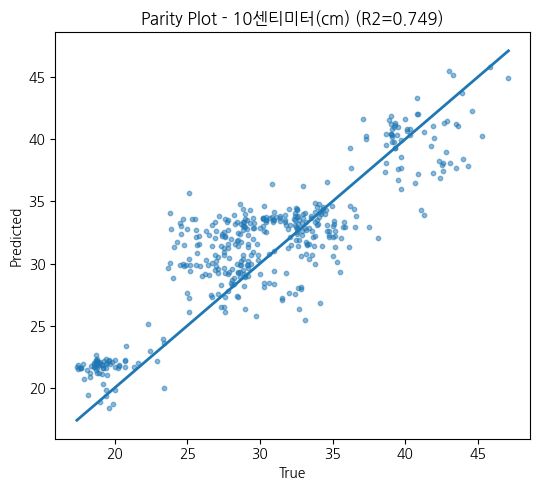

In [17]:
def plot_parity(target_key, n_points=2000):
    model.fit(X_train, y_train_dict[target_key])
    preds = model.predict(X_test)
    y_true = y_test_dict[target_key]

    if len(y_true) > n_points:
        idx = np.random.RandomState(42).choice(len(y_true), size=n_points, replace=False)
        y_true = y_true.iloc[idx] if hasattr(y_true, "iloc") else y_true[idx]
        preds  = preds[idx]

    r2 = r2_score(y_true, preds)

    plt.figure(figsize=(5.5,5))
    plt.scatter(y_true, preds, s=10, alpha=0.5)
    mn, mx = float(np.min([y_true.min(), preds.min()])), float(np.max([y_true.max(), preds.max()]))
    plt.plot([mn, mx], [mn, mx], linewidth=2)
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(f"Parity Plot - {target_key} (R2={r2:.3f})")
    plt.tight_layout()
    plt.show()


plot_parity("10센티미터(cm)")


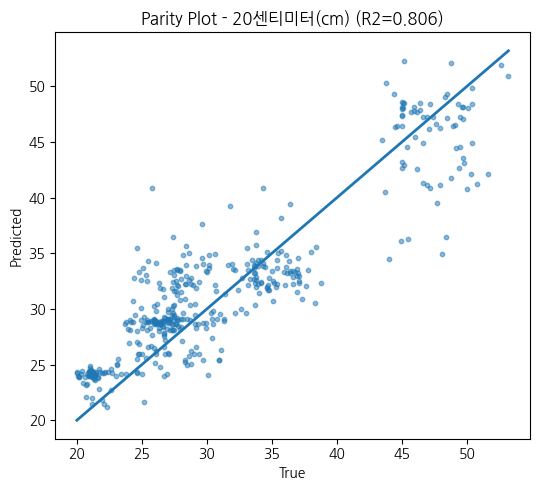

In [18]:

plot_parity("20센티미터(cm)")


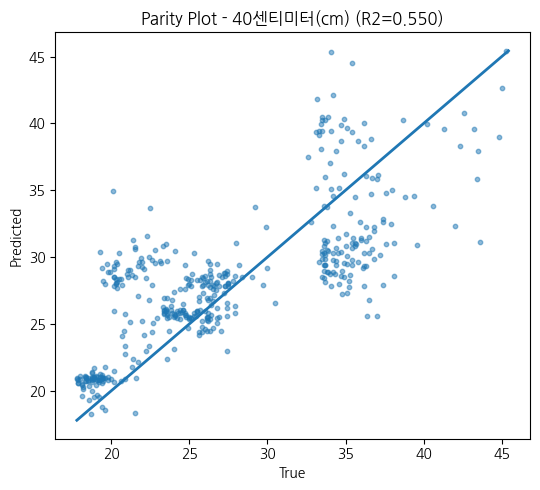

In [19]:

plot_parity("40센티미터(cm)")


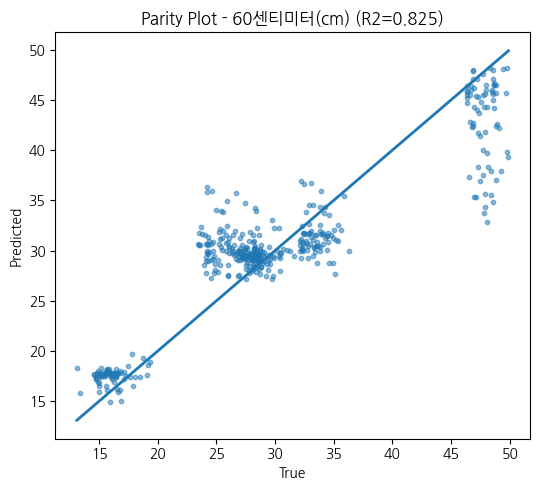

In [20]:

plot_parity("60센티미터(cm)")


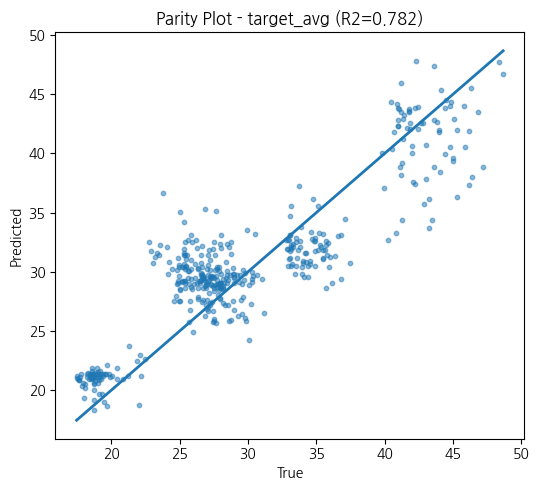

In [28]:

plot_parity("target_avg")


In [21]:
res_df = pd.read_csv("/results/results_log.csv")

display(res_df.sort_values(["target","test_RMSE"]).head(20))

# 타겟별 Best (RMSE 최소)
best_by_target = res_df.sort_values(["target","test_RMSE"]).groupby("target", as_index=False).first()
print("\n=== 타겟별 Best Model (Test RMSE 기준) ===")
display(best_by_target[["target","model","test_MAE","test_RMSE","test_R2","best_params"]])

# 모델별로 '개별 타겟 평균 vs 평균 타겟' 성능 비교
indiv_mean = res_df[res_df["target"]!="target_avg"].groupby("model")[["test_MAE","test_RMSE","test_R2"]].mean().add_suffix("_indiv_mean")
avg_only  = res_df[res_df["target"]=="target_avg"][["model","test_MAE","test_RMSE","test_R2"]].set_index("model").add_suffix("_avg_target")
compare = indiv_mean.join(avg_only, how="inner")
print("\n=== 개별 타겟 평균 vs 평균 타겟 성능 비교 (모델별) ===")
display(compare.sort_values("test_RMSE_avg_target"))


,timestamp,target,model,cv_scoring,cv_best_score_negMSE,cv_best_RMSE_est,test_MAE,test_RMSE,test_R2,best_params,model_path,cv_path
6,2025-08-23T09:15:26.907996+09:00,10센티미터(cm),XGBoost,neg_mean_squared_error,-49.510928,7.036400,2.565947,3.324934,0.755547,"{""model__colsample_bytree"": 1.0, ""model__learn...",artifacts_live/models/best_10센티미터(cm)_XGBoost....,artifacts_live/cv/cv_10센티미터(cm)_XGBoost.csv
4,2025-08-23T09:07:13.607542+09:00,10센티미터(cm),RandomForest,neg_mean_squared_error,-50.217011,7.086396,2.715514,3.359426,0.750449,"{""model__max_depth"": null, ""model__min_samples...",artifacts_live/models/best_10센티미터(cm)_RandomFo...,artifacts_live/cv/cv_10센티미터(cm)_RandomForest.csv
8,2025-08-23T09:57:31.116109+09:00,10센티미터(cm),CatBoost,neg_mean_squared_error,-49.942217,7.066981,2.700173,3.380827,0.747259,"{""model__depth"": 8, ""model__iterations"": 1200,...",artifacts_live/models/best_10센티미터(cm)_CatBoost...,artifacts_live/cv/cv_10센티미터(cm)_CatBoost.csv
7,2025-08-23T09:32:41.334959+09:00,10센티미터(cm),LightGBM,neg_mean_squared_error,-54.663762,7.393495,2.653357,3.413494,0.742351,"{""model__learning_rate"": 0.1, ""model__max_dept...",artifacts_live/models/best_10센티미터(cm)_LightGBM...,artifacts_live/cv/cv_10센티미터(cm)_LightGBM.csv
5,2025-08-23T09:09:28.194357+09:00,10센티미터(cm),GradientBoosting,neg_mean_squared_error,-57.621385,7.590875,3.254681,4.115318,0.625513,"{""model__learning_rate"": 0.05, ""model__max_dep...",artifacts_live/models/best_10센티미터(cm)_Gradient...,artifacts_live/cv/cv_10센티미터(cm)_GradientBoosti...
3,2025-08-23T08:59:24.051714+09:00,10센티미터(cm),ElasticNet,neg_mean_squared_error,-73.489774,8.572618,5.251152,6.148760,0.164003,"{""model__alpha"": 0.5, ""model__l1_ratio"": 0.8}",artifacts_live/models/best_10센티미터(cm)_ElasticN...,artifacts_live/cv/cv_10센티미터(cm)_ElasticNet.csv
2,2025-08-23T08:59:21.349395+09:00,10센티미터(cm),Lasso,neg_mean_squared_error,-76.800145,8.763569,5.580536,7.856197,-0.364754,"{""model__alpha"": 0.1}",artifacts_live/models/best_10센티미터(cm)_Lasso.jo...,artifacts_live/cv/cv_10센티미터(cm)_Lasso.csv
1,2025-08-23T08:59:19.072162+09:00,10센티미터(cm),Ridge,neg_mean_squared_error,-76.734828,8.759842,6.292363,10.799298,-1.578818,"{""model__alpha"": 100.0}",artifacts_live/models/best_10센티미터(cm)_Ridge.jo...,artifacts_live/cv/cv_10센티미터(cm)_Ridge.csv
0,2025-08-23T08:59:18.482654+09:00,10센티미터(cm),LinearRegression,neg_mean_squared_error,-92.594477,9.622602,6.469848,12.878515,-2.667425,"{""model__fit_intercept"": true}",artifacts_live/models/best_10센티미터(cm)_LinearRe...,artifacts_live/cv/cv_10센티미터(cm)_LinearRegressi...
14,2025-08-23T10:07:57.739951+09:00,20센티미터(cm),GradientBoosting,neg_mean_squared_error,-58.359345,7.639329,2.543624,3.201121,0.855983,"{""model__learning_rate"": 0.1, ""model__max_dept...",artifacts_live/models/best_20센티미터(cm)_Gradient...,artifacts_live/cv/cv_20센티미터(cm)_GradientBoosti...



=== 타겟별 Best Model (Test RMSE 기준) ===


,target,model,test_MAE,test_RMSE,test_R2,best_params
0,10센티미터(cm),XGBoost,2.565947,3.324934,0.755547,"{""model__colsample_bytree"": 1.0, ""model__learn..."
1,20센티미터(cm),GradientBoosting,2.543624,3.201121,0.855983,"{""model__learning_rate"": 0.1, ""model__max_dept..."
2,40센티미터(cm),CatBoost,3.332505,4.317719,0.585842,"{""model__depth"": 6, ""model__iterations"": 800, ..."
3,60센티미터(cm),CatBoost,2.489825,3.257762,0.885702,"{""model__depth"": 6, ""model__iterations"": 800, ..."
4,target_avg,XGBoost,2.476347,3.235273,0.820386,"{""model__colsample_bytree"": 1.0, ""model__learn..."



=== 개별 타겟 평균 vs 평균 타겟 성능 비교 (모델별) ===


,test_MAE_indiv_mean,test_RMSE_indiv_mean,test_R2_indiv_mean,test_MAE_avg_target,test_RMSE_avg_target,test_R2_avg_target
model,,,,,,
XGBoost,2.738724,3.585324,0.765654,2.476347,3.235273,0.820386
GradientBoosting,3.015757,3.873545,0.725462,2.623030,3.248788,0.818882
CatBoost,2.777646,3.557010,0.767091,2.632421,3.335663,0.809066
LightGBM,2.830775,3.743295,0.747054,2.623723,3.367982,0.805348
RandomForest,3.054641,3.908124,0.732021,2.870211,3.582874,0.779717
ElasticNet,6.138972,7.709248,0.055810,5.841970,6.676981,0.234970
Lasso,6.061501,7.634102,0.035006,5.973014,7.361143,0.070158
Ridge,6.787887,10.315095,-0.772587,6.686469,10.098587,-0.750006
LinearRegression,7.060825,12.406592,-1.568258,6.941504,12.231401,-1.567266


In [29]:
import pandas as pd
import numpy as np

CSV_PATH = "results/results_log.csv"
res_df = pd.read_csv(CSV_PATH)


pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.3f}".format)

# ===== [A] 상위 20개 (target, RMSE 오름차순) =====
top20 = res_df.sort_values(["target","test_RMSE"]).head(20).copy()
top20_cols_order = ["target","model","test_MAE","test_RMSE","test_R2","cv_best_score_negRMSE","best_params"]
top20 = top20[[c for c in top20_cols_order if c in top20.columns]]

def style_top20(df):
    return (
        df.style
          .set_caption("상위 20개 결과 (target별 RMSE 오름차순)")
          .format({"test_MAE": "{:.3f}", "test_RMSE": "{:.3f}", "test_R2": "{:.3f}", "cv_best_score_negRMSE": "{:.3f}"})
          .background_gradient(subset=["test_RMSE"], cmap="YlOrRd_r")
          .background_gradient(subset=["test_R2"], cmap="YlGn")
          .set_properties(subset=["target","model"], **{"font-weight": "bold"})
          .hide(axis="index")
    )

display(style_top20(top20))

# ===== [B] 타깃별 Best (RMSE 최소) =====
best_by_target = (res_df
                  .sort_values(["target","test_RMSE"])
                  .groupby("target", as_index=False)
                  .first())

best_cols = ["target","model","test_MAE","test_RMSE","test_R2","best_params"]
best_view = best_by_target[best_cols].copy()

def style_best(df):
    return (
        df.style
          .set_caption("타깃별 Best Model (Test RMSE 기준)")
          .format({"test_MAE": "{:.3f}", "test_RMSE": "{:.3f}", "test_R2": "{:.3f}"})
          .bar(subset=["test_R2"], color="#a6d854", vmin=0, vmax=1)
          .background_gradient(subset=["test_RMSE"], cmap="YlOrRd_r")
          .set_properties(subset=["target","model"], **{"font-weight": "bold"})
          .hide(axis="index")
    )

display(style_best(best_view))

# ===== [C] 모델별 '개별 타깃 평균 vs 평균 타깃' 비교 =====
indiv_mean = (res_df[res_df["target"]!="target_avg"]
              .groupby("model")[["test_MAE","test_RMSE","test_R2"]]
              .mean()
              .add_suffix("_indiv_mean"))
avg_only  = (res_df[res_df["target"]=="target_avg"][["model","test_MAE","test_RMSE","test_R2"]]
             .set_index("model").add_suffix("_avg_target"))
compare = indiv_mean.join(avg_only, how="inner")


compare = compare.sort_values("test_RMSE_avg_target").reset_index()

def style_compare(df):
    fmt_cols = [c for c in df.columns if c != "model"]
    return (
        df.style
          .set_caption("모델별: 개별 타깃 평균 vs 평균 타깃 성능 비교")
          .format({col: "{:.3f}" for col in fmt_cols})
          .background_gradient(subset=["test_RMSE_indiv_mean","test_RMSE_avg_target"], cmap="YlOrRd_r")
          .background_gradient(subset=["test_R2_indiv_mean","test_R2_avg_target"], cmap="YlGn")
          .set_properties(subset=["model"], **{"font-weight": "bold"})
          .hide(axis="index")
    )

display(style_compare(compare))


target,model,test_MAE,test_RMSE,test_R2,best_params
10센티미터(cm),XGBoost,2.566,3.325,0.756,"{""model__colsample_bytree"": 1.0, ""model__learning_rate"": 0.1, ""model__max_depth"": 5, ""model__n_estimators"": 800, ""model__subsample"": 0.7}"
10센티미터(cm),RandomForest,2.716,3.359,0.750,"{""model__max_depth"": null, ""model__min_samples_leaf"": 1, ""model__n_estimators"": 600}"
10센티미터(cm),CatBoost,2.700,3.381,0.747,"{""model__depth"": 8, ""model__iterations"": 1200, ""model__l2_leaf_reg"": 5, ""model__learning_rate"": 0.05}"
10센티미터(cm),LightGBM,2.653,3.413,0.742,"{""model__learning_rate"": 0.1, ""model__max_depth"": -1, ""model__n_estimators"": 800, ""model__num_leaves"": 31}"
10센티미터(cm),GradientBoosting,3.255,4.115,0.626,"{""model__learning_rate"": 0.05, ""model__max_depth"": 2, ""model__n_estimators"": 300}"
10센티미터(cm),ElasticNet,5.251,6.149,0.164,"{""model__alpha"": 0.5, ""model__l1_ratio"": 0.8}"
10센티미터(cm),Lasso,5.581,7.856,-0.365,"{""model__alpha"": 0.1}"
10센티미터(cm),Ridge,6.292,10.799,-1.579,"{""model__alpha"": 100.0}"
10센티미터(cm),LinearRegression,6.470,12.879,-2.667,"{""model__fit_intercept"": true}"
20센티미터(cm),GradientBoosting,2.544,3.201,0.856,"{""model__learning_rate"": 0.1, ""model__max_depth"": 4, ""model__n_estimators"": 600}"


target,model,test_MAE,test_RMSE,test_R2,best_params
10센티미터(cm),XGBoost,2.566,3.325,0.756,"{""model__colsample_bytree"": 1.0, ""model__learning_rate"": 0.1, ""model__max_depth"": 5, ""model__n_estimators"": 800, ""model__subsample"": 0.7}"
20센티미터(cm),GradientBoosting,2.544,3.201,0.856,"{""model__learning_rate"": 0.1, ""model__max_depth"": 4, ""model__n_estimators"": 600}"
40센티미터(cm),CatBoost,3.333,4.318,0.586,"{""model__depth"": 6, ""model__iterations"": 800, ""model__l2_leaf_reg"": 5, ""model__learning_rate"": 0.05}"
60센티미터(cm),CatBoost,2.490,3.258,0.886,"{""model__depth"": 6, ""model__iterations"": 800, ""model__l2_leaf_reg"": 1, ""model__learning_rate"": 0.05}"
target_avg,XGBoost,2.476,3.235,0.820,"{""model__colsample_bytree"": 1.0, ""model__learning_rate"": 0.05, ""model__max_depth"": 5, ""model__n_estimators"": 800, ""model__subsample"": 0.7}"


model,test_MAE_indiv_mean,test_RMSE_indiv_mean,test_R2_indiv_mean,test_MAE_avg_target,test_RMSE_avg_target,test_R2_avg_target
XGBoost,2.739,3.585,0.766,2.476,3.235,0.820
GradientBoosting,3.016,3.874,0.725,2.623,3.249,0.819
CatBoost,2.778,3.557,0.767,2.632,3.336,0.809
LightGBM,2.831,3.743,0.747,2.624,3.368,0.805
RandomForest,3.055,3.908,0.732,2.870,3.583,0.780
ElasticNet,6.139,7.709,0.056,5.842,6.677,0.235
Lasso,6.062,7.634,0.035,5.973,7.361,0.070
Ridge,6.788,10.315,-0.773,6.686,10.099,-0.750
LinearRegression,7.061,12.407,-1.568,6.942,12.231,-1.567


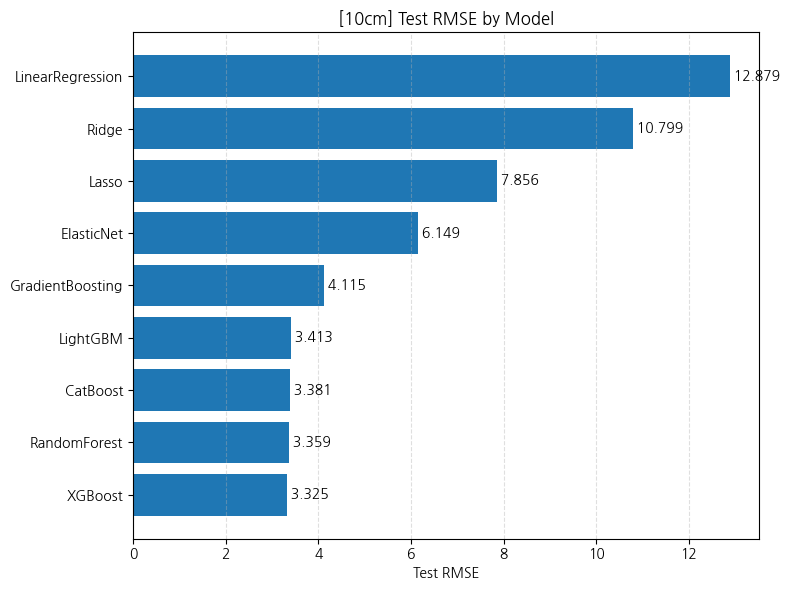

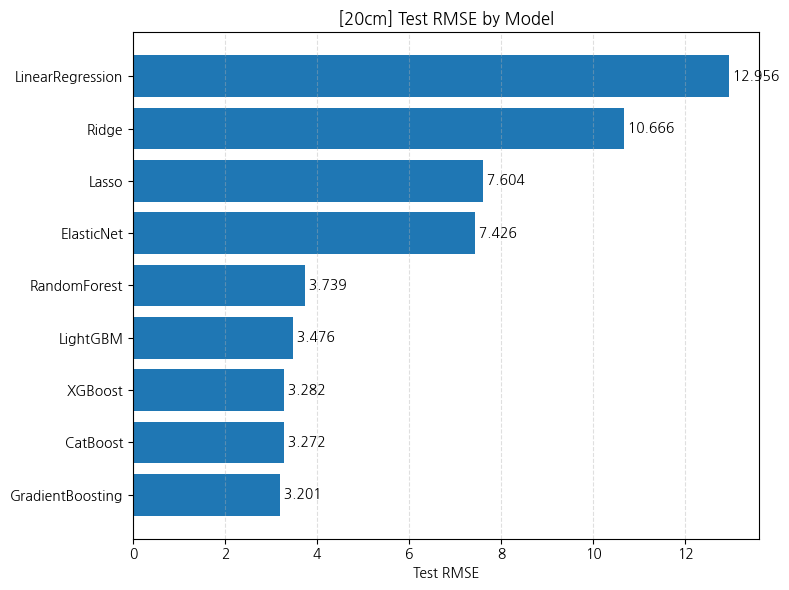

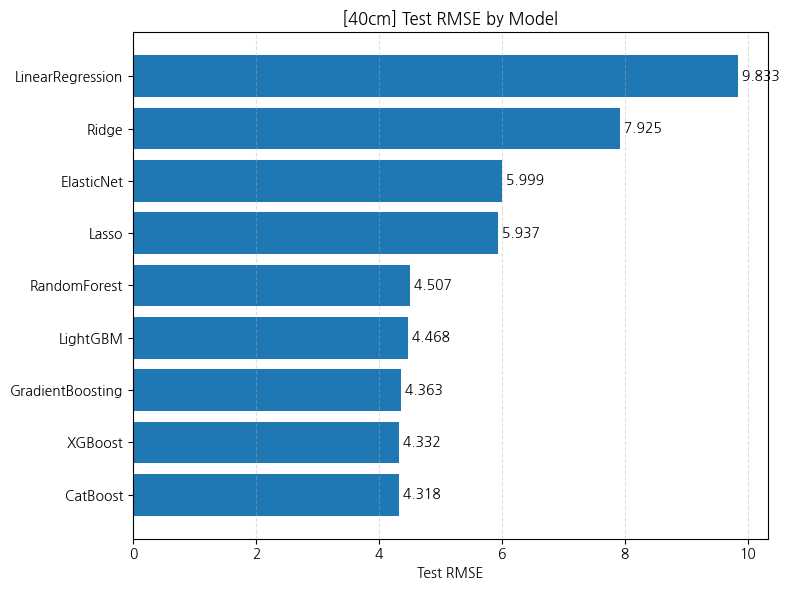

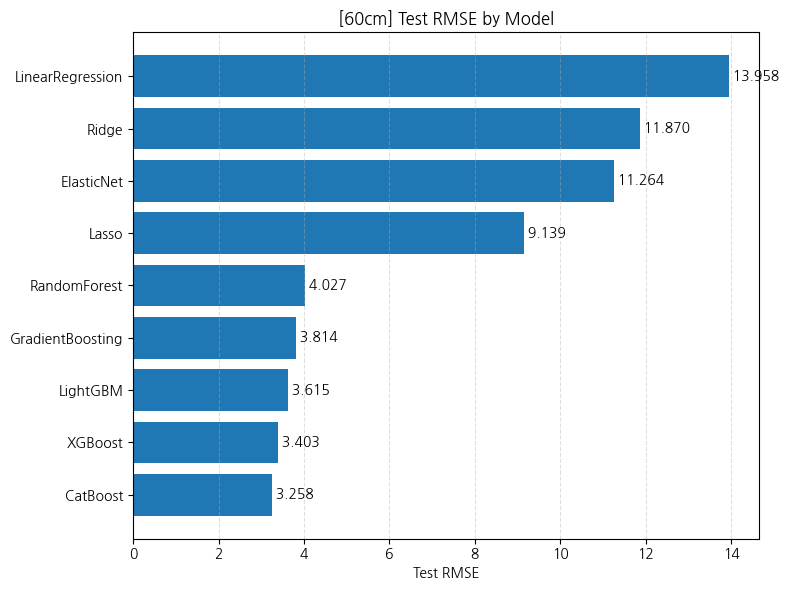

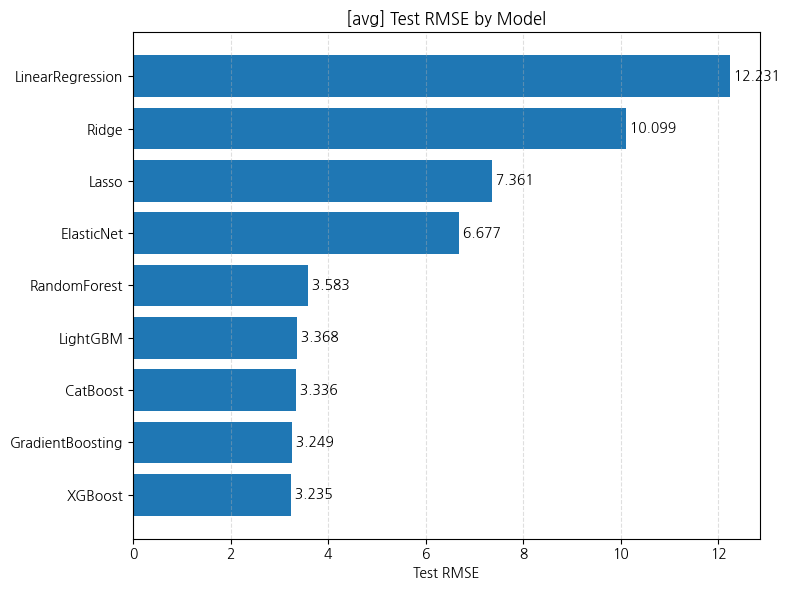

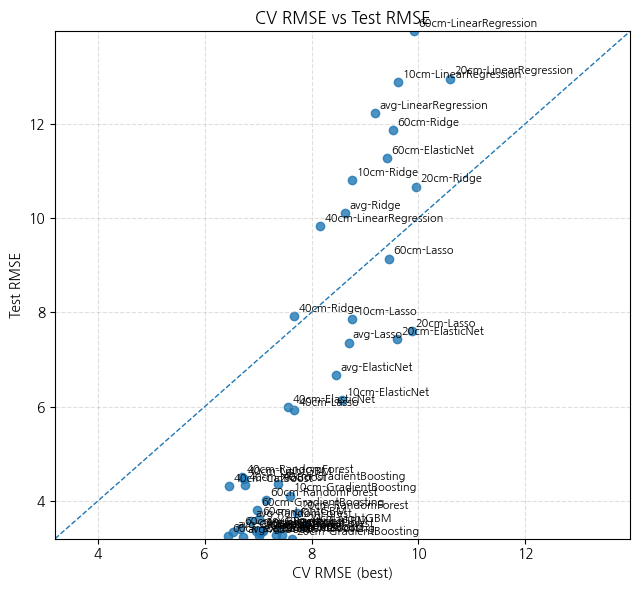

/tmp/ipython-input-1423020857.py:92: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


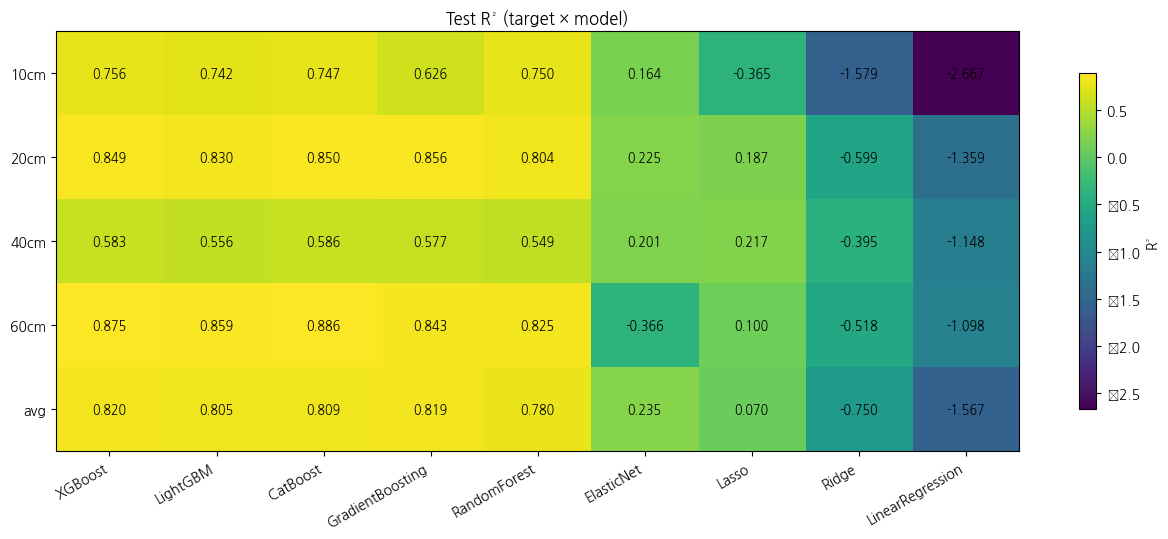

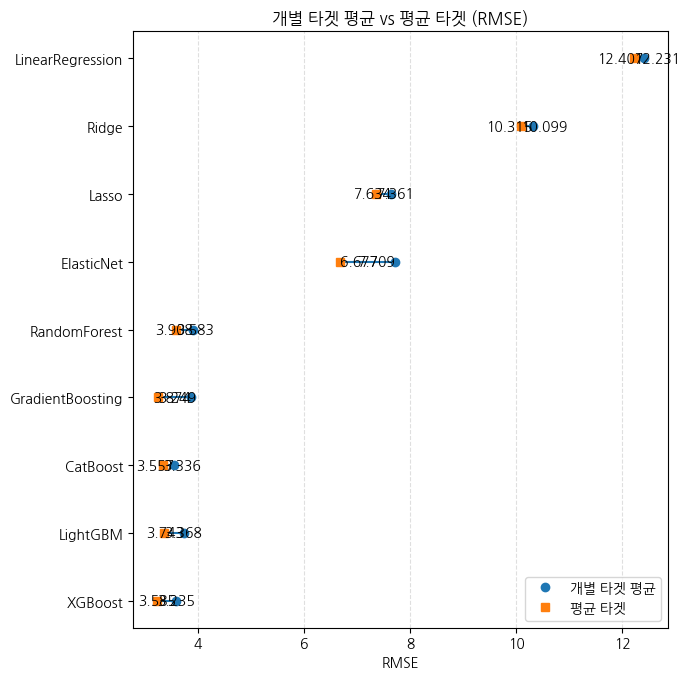

,target,model,test_MAE,test_RMSE,test_R2,best_params
0,10센티미터(cm),XGBoost,2.565947,3.324934,0.755547,"{""model__colsample_bytree"": 1.0, ""model__learn..."
1,20센티미터(cm),GradientBoosting,2.543624,3.201121,0.855983,"{""model__learning_rate"": 0.1, ""model__max_dept..."
2,40센티미터(cm),CatBoost,3.332505,4.317719,0.585842,"{""model__depth"": 6, ""model__iterations"": 800, ..."
3,60센티미터(cm),CatBoost,2.489825,3.257762,0.885702,"{""model__depth"": 6, ""model__iterations"": 800, ..."
4,target_avg,XGBoost,2.476347,3.235273,0.820386,"{""model__colsample_bytree"": 1.0, ""model__learn..."


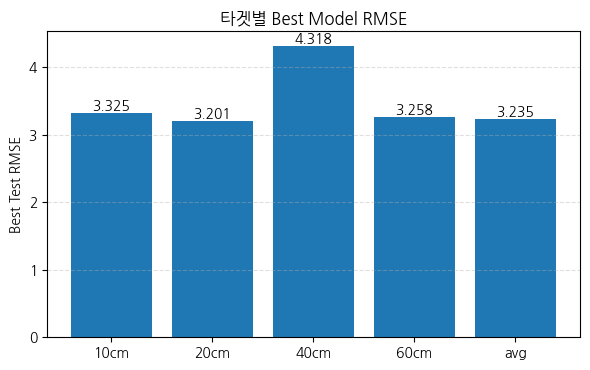

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


if 'compare' not in globals():
    indiv_mean = res_df[res_df["target"]!="target_avg"] \
        .groupby("model")[["test_MAE","test_RMSE","test_R2"]].mean().add_suffix("_indiv_mean")
    avg_only  = res_df[res_df["target"]=="target_avg"][["model","test_MAE","test_RMSE","test_R2"]] \
        .set_index("model").add_suffix("_avg_target")
    compare = indiv_mean.join(avg_only, how="inner")

targets = ["10센티미터(cm)","20센티미터(cm)","40센티미터(cm)","60센티미터(cm)","target_avg"]
target_labels = {
    "10센티미터(cm)":"10cm", "20센티미터(cm)":"20cm",
    "40센티미터(cm)":"40cm", "60센티미터(cm)":"60cm",
    "target_avg":"avg"
}
model_order = ["XGBoost","LightGBM","CatBoost","GradientBoosting",
               "RandomForest","ElasticNet","Lasso","Ridge","LinearRegression"]

def add_value_labels(ax, fmt="{:.3f}", fontsize=10):
    for p in ax.patches:
        if p.get_width() > 0:
            ax.text(p.get_width(), p.get_y()+p.get_height()/2,
                    " "+fmt.format(p.get_width()),
                    va="center", ha="left", fontsize=fontsize)

# == 1) 타겟별 Test RMSE Bar charts ==
for tgt in targets:
    d = res_df[res_df["target"]==tgt].copy()
    if d.empty:
        continue
    d["model"] = pd.Categorical(d["model"], categories=model_order, ordered=True)
    d = d.sort_values("test_RMSE", ascending=True)

    fig, ax = plt.subplots(figsize=(8, 0.5*len(d)+1.5))
    ax.barh(d["model"], d["test_RMSE"])
    ax.set_title(f"[{target_labels.get(tgt, tgt)}] Test RMSE by Model")
    ax.set_xlabel("Test RMSE")
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    add_value_labels(ax)
    fig.tight_layout()
    plt.show()

# == 2) CV vs Test RMSE Scatter ==
dfp = res_df.dropna(subset=["cv_best_RMSE_est","test_RMSE"]).copy()
fig, ax = plt.subplots(figsize=(6.5,6))
ax.scatter(dfp["cv_best_RMSE_est"], dfp["test_RMSE"], alpha=0.8)


lims = [min(dfp["cv_best_RMSE_est"].min(), dfp["test_RMSE"].min()),
        max(dfp["cv_best_RMSE_est"].max(), dfp["test_RMSE"].max())]
ax.plot(lims, lims, linestyle="--", linewidth=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("CV RMSE (best)")
ax.set_ylabel("Test RMSE")
ax.set_title("CV RMSE vs Test RMSE")
ax.grid(True, linestyle="--", alpha=0.4)


for _, r in dfp.iterrows():
    short_t = target_labels.get(r["target"], r["target"])
    m = r["model"]
    ax.annotate(f"{short_t}-{m}", (r["cv_best_RMSE_est"], r["test_RMSE"]),
                xytext=(3,3), textcoords="offset points", fontsize=8)

fig.tight_layout()
plt.show()

# == 3) 타겟×모델 Test R² Heatmap ==
pivot_r2 = res_df.pivot_table(index="target", columns="model", values="test_R2", aggfunc="first")
pivot_r2 = pivot_r2.reindex(index=targets, columns=[c for c in model_order if c in pivot_r2.columns])

fig, ax = plt.subplots(figsize=(1.2*len(pivot_r2.columns)+2, 0.8*len(pivot_r2.index)+1.5))
im = ax.imshow(pivot_r2.values, aspect="auto")
ax.set_xticks(range(len(pivot_r2.columns)))
ax.set_yticks(range(len(pivot_r2.index)))
ax.set_xticklabels(pivot_r2.columns, rotation=30, ha="right")
ax.set_yticklabels([target_labels.get(t, t) for t in pivot_r2.index])
ax.set_title("Test R² (target × model)")

for i in range(pivot_r2.shape[0]):
    for j in range(pivot_r2.shape[1]):
        v = pivot_r2.values[i,j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.8, label="R²")
fig.tight_layout()
plt.show()

# == 4) 모델별 '개별 타겟 평균 vs 평균 타겟' Dumbbell Chart (RMSE) ==
d = compare[["test_RMSE_indiv_mean","test_RMSE_avg_target"]].copy()
d = d.loc[[m for m in model_order if m in d.index]]
fig, ax = plt.subplots(figsize=(7, 0.6*len(d)+1.5))
y = np.arange(len(d))
ax.hlines(y, d["test_RMSE_indiv_mean"], d["test_RMSE_avg_target"])
ax.plot(d["test_RMSE_indiv_mean"], y, 'o', label="개별 타겟 평균")
ax.plot(d["test_RMSE_avg_target"],  y, 's', label="평균 타겟")
ax.set_yticks(y); ax.set_yticklabels(d.index)
ax.set_xlabel("RMSE")
ax.set_title("개별 타겟 평균 vs 평균 타겟 (RMSE)")
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.legend(loc="lower right")

for i, (a,b) in enumerate(zip(d["test_RMSE_indiv_mean"], d["test_RMSE_avg_target"])):
    ax.text(a, i, f"{a:.3f}", va="center", ha="right")
    ax.text(b, i, f"{b:.3f}", va="center", ha="left")
fig.tight_layout()
plt.show()

# == 5) 타겟별 Best 표 + Bar charts ==
best_by_target = res_df.sort_values(["target","test_RMSE"]).groupby("target", as_index=False).first()
display(best_by_target[["target","model","test_MAE","test_RMSE","test_R2","best_params"]])

d = best_by_target.copy()
d["short_t"] = d["target"].map(target_labels).fillna(d["target"])
d = d.set_index("short_t")

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.bar(d.index, d["test_RMSE"])
for i, v in enumerate(d["test_RMSE"]):
    ax.text(i, v, f"{v:.3f}", ha="center", va="bottom")
ax.set_ylabel("Best Test RMSE")
ax.set_title("타겟별 Best Model RMSE")
ax.grid(axis="y", linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()



=== Permutation Importance: XGBoost | Target: 10센티미터(cm) ===


,feature,importance_mean,importance_std
11,num__기압_PA_MAX,0.842124,0.028809
12,num__기압_PA_MIN,0.186688,0.011688
9,num__강수량_RN_MAX_6HR,0.087229,0.013660
18,num__바람_WS_DAVG,0.077213,0.004829
10,num__기압_PA_MAVG,0.062137,0.005517
24,num__이슬점온도_TD_MIN,0.035136,0.002627
19,num__바람_WS_INS_MAX,0.027721,0.003578
34,num__시정_VS_MIN,0.017652,0.002247
13,num__기압_PS_MAX,0.012447,0.003385
39,num__일조_SSRATE,0.011082,0.002339


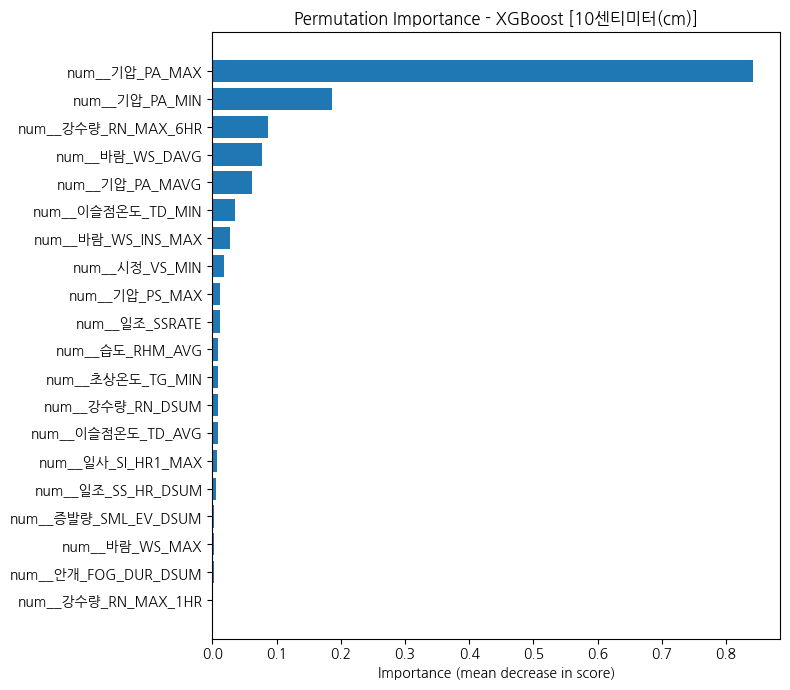


=== Permutation Importance: GradientBoosting | Target: 20센티미터(cm) ===


,feature,importance_mean,importance_std
11,num__기압_PA_MAX,0.737440,0.020990
12,num__기압_PA_MIN,0.369697,0.026491
10,num__기압_PA_MAVG,0.175041,0.014076
13,num__기압_PS_MAX,0.114298,0.011057
18,num__바람_WS_DAVG,0.112089,0.007729
9,num__강수량_RN_MAX_6HR,0.060010,0.014542
19,num__바람_WS_INS_MAX,0.054121,0.003879
24,num__이슬점온도_TD_MIN,0.016851,0.001721
22,num__이슬점온도_TD_AVG,0.008673,0.002198
20,num__바람_WS_MAX,0.008091,0.001718


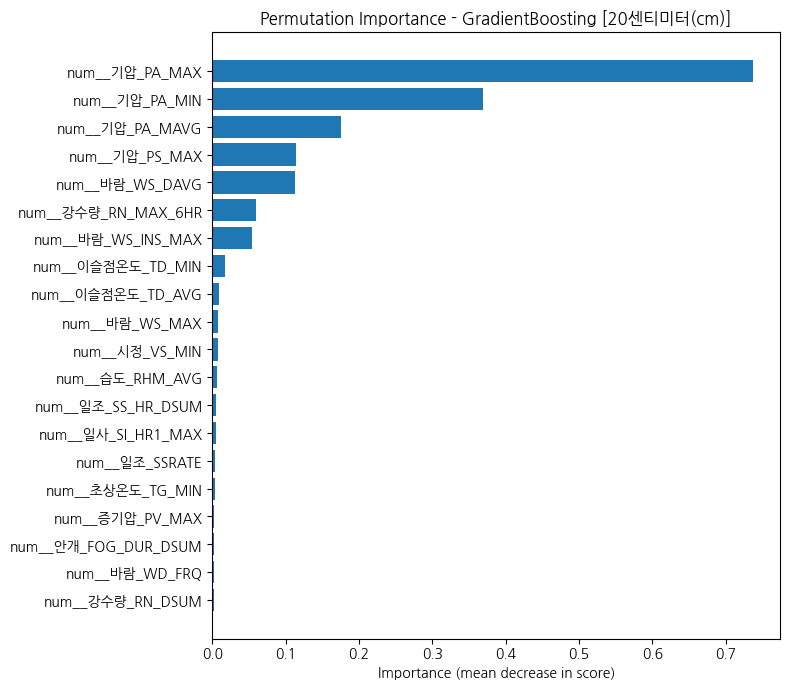


=== Permutation Importance: CatBoost | Target: 40센티미터(cm) ===


,feature,importance_mean,importance_std
11,num__기압_PA_MAX,0.226034,0.015860
12,num__기압_PA_MIN,0.164879,0.014470
10,num__기압_PA_MAVG,0.122061,0.014549
34,num__시정_VS_MIN,0.044728,0.008456
9,num__강수량_RN_MAX_6HR,0.043136,0.009037
18,num__바람_WS_DAVG,0.033303,0.008526
39,num__일조_SSRATE,0.022755,0.003529
13,num__기압_PS_MAX,0.016437,0.004026
38,num__일사_SI_HR1_MAX,0.015478,0.002706
19,num__바람_WS_INS_MAX,0.013795,0.001668


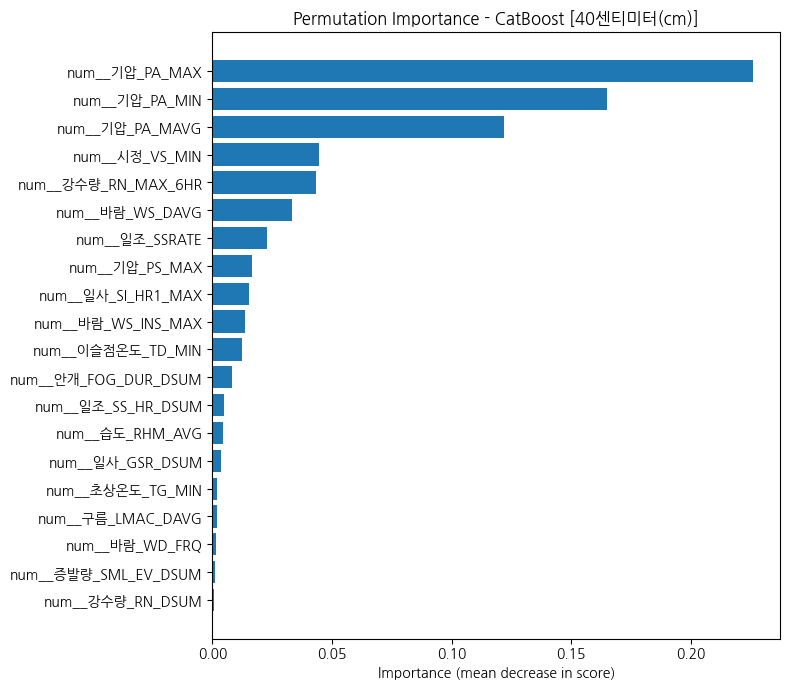

CatBoostError: You can't change params of fitted model.

In [24]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from ast import literal_eval

import math, warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import GridSearchCV, KFold, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    xgb_available = True
except Exception:
    xgb_available = False

try:
    from lightgbm import LGBMRegressor
    lgb_available = True
except Exception:
    lgb_available = False

try:
    from catboost import CatBoostRegressor
    cb_available = True
except Exception:
    cb_available = False


cv = TimeSeriesSplit(n_splits=3)

tree_like = {"RandomForest","GradientBoosting","XGBoost","LightGBM","CatBoost"}


models_and_grids = []

# 선형 계열
models_and_grids.append((
    "LinearRegression",
    Pipeline([("prep", preprocessor), ("model", LinearRegression())]),
    {"model__fit_intercept": [True, False]}
))

models_and_grids.append((
    "Ridge",
    Pipeline([("prep", preprocessor), ("model", Ridge(random_state=42))]),
    {"model__alpha": [0.1, 1.0, 10.0, 100.0]}
))

models_and_grids.append((
    "Lasso",
    Pipeline([("prep", preprocessor), ("model", Lasso(random_state=42, max_iter=10000))]),
    {"model__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0]}
))

models_and_grids.append((
    "ElasticNet",
    Pipeline([("prep", preprocessor), ("model", ElasticNet(random_state=42, max_iter=10000))]),
    {"model__alpha": [0.0005, 0.005, 0.05, 0.5],
     "model__l1_ratio": [0.2, 0.5, 0.8]}
))

# 트리/부스팅
models_and_grids.append((
    "RandomForest",
    Pipeline([("prep", preprocessor), ("model", RandomForestRegressor(random_state=42, n_jobs=-1))]),
    {"model__n_estimators": [300, 600],
     "model__max_depth": [None, 8, 12],
     "model__min_samples_leaf": [1, 3, 5]}
))

models_and_grids.append((
    "GradientBoosting",
    Pipeline([("prep", preprocessor), ("model", GradientBoostingRegressor(random_state=42))]),
    {"model__n_estimators": [300, 600],
     "model__learning_rate": [0.05, 0.1],
     "model__max_depth": [2, 3, 4]}
))

if xgb_available:
    models_and_grids.append((
        "XGBoost",
        Pipeline([("prep", preprocessor), ("model", XGBRegressor(random_state=42, n_jobs=-1, objective="reg:squarederror"))]),
        {"model__n_estimators": [400, 800],
         "model__max_depth": [3, 5, 7],
         "model__learning_rate": [0.05, 0.1],
         "model__subsample": [0.7, 1.0],
         "model__colsample_bytree": [0.7, 1.0]}
    ))

if lgb_available:
    models_and_grids.append((
        "LightGBM",
        Pipeline([("prep", preprocessor), ("model", LGBMRegressor(random_state=42, n_jobs=-1))]),
        {"model__n_estimators": [400, 800],
         "model__num_leaves": [31, 63, 127],
         "model__learning_rate": [0.05, 0.1],
         "model__max_depth": [-1, 8, 12]}
    ))

if cb_available:
    models_and_grids.append((
        "CatBoost",
        Pipeline([("prep", preprocessor), ("model", CatBoostRegressor(random_state=42, verbose=False))]),
        {"model__iterations": [800, 1200],
         "model__depth": [4, 6, 8],
         "model__learning_rate": [0.05, 0.1],
         "model__l2_leaf_reg": [1, 3, 5]}
    ))


# 타겟별 베스트 중 트리계열만 추려서 중요도 계산
for _, row in best_by_target.iterrows():
    tgt = row["target"]
    model_name = row["model"]
    if model_name not in tree_like:
        continue

    # 해당 모델 파이프라인 재생성 + 베스트 파라미터 적용
    # (위의 models_and_grids에서 동일 모델명 찾아서 파이프라인 꺼내기)
    for name, pipe, grid in models_and_grids:
        if name == model_name:
            best_pipe = Pipeline(steps=pipe.steps)
            # best params를 set
            for k, v in literal_eval(row["best_params"]).items():
                best_pipe.set_params(**{k: v})
            break

    # 학습 및 Permutation Importance
    y_train = y_train_dict[tgt]
    y_test  = y_test_dict[tgt]

    best_pipe.fit(X_train, y_train)
    perm = permutation_importance(
        best_pipe, X_test, y_test,
        n_repeats=5, random_state=42, n_jobs=-1
    )

    feat_names = best_pipe.named_steps["prep"].get_feature_names_out()
    imp_df = pd.DataFrame({
        "feature": feat_names,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values("importance_mean", ascending=False)

    top_k = 20
    top_imp = imp_df.head(top_k)

    print(f"\n=== Permutation Importance: {model_name} | Target: {tgt} ===")
    display(top_imp)

    # 수평 Bar charts
    fig, ax = plt.subplots(figsize=(8, max(4, len(top_imp)*0.35)))
    ax.barh(top_imp["feature"], top_imp["importance_mean"])
    ax.set_xlabel("Importance (mean decrease in score)")
    ax.set_title(f"Permutation Importance - {model_name} [{tgt}]")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


### 기압 데이터 검증

In [31]:
import numpy as np, pandas as pd
from copy import deepcopy

# ❶ "기압" 컬럼 패턴
PRESSURE_PATTERNS = ["기압"]

def is_pressure(col: str) -> bool:
    return any(pat in col for pat in PRESSURE_PATTERNS)

pressure_cols     = [c for c in X_train.columns if is_pressure(c)]
non_pressure_cols = [c for c in X_train.columns if not is_pressure(c)]
print(f"[압력 변수 개수] {len(pressure_cols)}\n", pressure_cols[:20])


[압력 변수 개수] 7
 ['기압_PA_MAVG', '기압_PA_MAX', '기압_PA_MIN', '기압_PS_MAX', '증기압_PV_DAVG', '증기압_PV_MAX', '증기압_PV_MIN']


In [32]:
def corr_tables(X: pd.DataFrame, y: pd.Series, pressure_cols):
    df = X.copy()
    df["__TARGET__"] = y.values

    pear = df.corr(method="pearson").loc[pressure_cols]
    spear = df.corr(method="spearman").loc[pressure_cols]

    # 타깃과의 상관만 따로
    pear_target = pear["__TARGET__"].sort_values(ascending=False).to_frame("pearson_with_target")
    spear_target = spear["__TARGET__"].sort_values(ascending=False).to_frame("spearman_with_target")

    return pear.drop(columns="__TARGET__", errors="ignore"), spear.drop(columns="__TARGET__", errors="ignore"), pear_target, spear_target

pear, spear, pear_t, spear_t = corr_tables(X_train, y_train_dict[tgt], pressure_cols)
print("=== Pearson (pressure × features) ==="); display(pear.iloc[:, :12].round(3))
print("=== Spearman (pressure × features) ==="); display(spear.iloc[:, :12].round(3))
print("=== pressure ↔ target (Pearson) ==="); display(pear_t.round(3))
print("=== pressure ↔ target (Spearman) ==="); display(spear_t.round(3))


=== Pearson (pressure × features) ===


,기온_DYTM_TMX,기온_MRNG_TMN,기온_NGHT_TMN,기온_TA_DAVG,기온_TMN_DD,기온_TMX_DD,강수량_RN_DSUM,강수량_RN_MAX_10M,강수량_RN_MAX_1HR,강수량_RN_MAX_6HR,기압_PA_MAVG,기압_PA_MAX
기압_PA_MAVG,0.163,0.065,0.080,0.129,0.074,0.164,-0.038,-0.067,-0.050,-0.213,1.000,0.995
기압_PA_MAX,0.166,0.069,0.083,0.133,0.078,0.167,-0.034,-0.067,-0.049,-0.210,0.995,1.000
기압_PA_MIN,0.166,0.071,0.085,0.133,0.080,0.167,-0.038,-0.064,-0.048,-0.208,0.978,0.972
기압_PS_MAX,-0.764,-0.834,-0.807,-0.827,-0.838,-0.767,-0.226,-0.293,-0.279,-0.217,0.089,0.090
증기압_PV_DAVG,0.827,0.940,0.929,0.906,0.947,0.831,0.229,0.363,0.321,0.208,-0.044,-0.044
증기압_PV_MAX,0.841,0.944,0.933,0.915,0.947,0.846,0.231,0.364,0.323,0.205,-0.044,-0.042
증기압_PV_MIN,0.796,0.922,0.910,0.879,0.931,0.799,0.221,0.361,0.316,0.208,-0.043,-0.044


=== Spearman (pressure × features) ===


,기온_DYTM_TMX,기온_MRNG_TMN,기온_NGHT_TMN,기온_TA_DAVG,기온_TMN_DD,기온_TMX_DD,강수량_RN_DSUM,강수량_RN_MAX_10M,강수량_RN_MAX_1HR,강수량_RN_MAX_6HR,기압_PA_MAVG,기압_PA_MAX
기압_PA_MAVG,0.034,-0.062,-0.045,-0.007,-0.053,0.035,-0.109,-0.188,-0.190,-0.247,1.000,0.989
기압_PA_MAX,0.025,-0.065,-0.049,-0.012,-0.057,0.027,-0.097,-0.184,-0.185,-0.238,0.989,1.000
기압_PA_MIN,0.049,-0.048,-0.031,0.007,-0.039,0.050,-0.121,-0.194,-0.195,-0.254,0.993,0.982
기압_PS_MAX,-0.751,-0.827,-0.803,-0.815,-0.830,-0.754,-0.170,-0.293,-0.289,-0.169,0.228,0.235
증기압_PV_DAVG,0.869,0.966,0.954,0.946,0.972,0.873,0.213,0.339,0.326,0.193,-0.149,-0.150
증기압_PV_MAX,0.871,0.962,0.950,0.944,0.964,0.874,0.224,0.349,0.337,0.202,-0.150,-0.150
증기압_PV_MIN,0.847,0.956,0.942,0.929,0.965,0.850,0.207,0.331,0.318,0.193,-0.145,-0.148


=== pressure ↔ target (Pearson) ===


,pearson_with_target
기압_PA_MAX,0.211
기압_PA_MAVG,0.207
기압_PA_MIN,0.204
기압_PS_MAX,0.113
증기압_PV_MIN,-0.117
증기압_PV_DAVG,-0.128
증기압_PV_MAX,-0.133


=== pressure ↔ target (Spearman) ===


,spearman_with_target
기압_PA_MAX,0.219
기압_PA_MAVG,0.215
기압_PA_MIN,0.210
기압_PS_MAX,0.111
증기압_PV_MIN,-0.134
증기압_PV_MAX,-0.142
증기압_PV_DAVG,-0.142


In [33]:
# 모델 1개 선택 (XGB > LGBM > CatBoost > RandomForest 순)
from sklearn.pipeline import Pipeline
try:
    from xgboost import XGBRegressor; base_model = XGBRegressor(random_state=42, n_jobs=-1, objective="reg:squarederror")
except Exception:
    try:
        from lightgbm import LGBMRegressor; base_model = LGBMRegressor(random_state=42, n_jobs=-1)
    except Exception:
        try:
            from catboost import CatBoostRegressor; base_model = CatBoostRegressor(random_state=42, verbose=False)
        except Exception:
            from sklearn.ensemble import RandomForestRegressor; base_model = RandomForestRegressor(random_state=42, n_jobs=-1)

est = Pipeline([("prep", preprocessor), ("model", base_model)])
est.fit(X_train, y_train_dict[tgt])

# 전처리 후 특징 이름
def get_feature_names_after_prep(prep, X: pd.DataFrame):
    try:
        names = list(prep.get_feature_names_out())
    except Exception:
        names = list(X.columns)  # 실패하면 원본 이름 사용
    return names

X_test_proc = est.named_steps["prep"].transform(X_test)
feat_names  = get_feature_names_after_prep(est.named_steps["prep"], X_train)

# SHAP
import shap
try:
    explainer = shap.TreeExplainer(est.named_steps["model"])
    shap_values = explainer.shap_values(X_test_proc)
    # 평균 |SHAP| 기준 상위 15
    mean_abs = np.abs(shap_values).mean(axis=0)
    top_idx  = np.argsort(-mean_abs)[:15]
    shap_rank = pd.DataFrame({
        "feature": np.array(feat_names)[top_idx],
        "mean_abs_shap": mean_abs[top_idx]
    })
    print("=== SHAP top 15 ==="); display(shap_rank)


except Exception as e:
    print("[WARN] SHAP 계산 실패:", e)


=== SHAP top 15 ===


,feature,mean_abs_shap
0,num__기압_PA_MAX,3.661
1,num__기압_PA_MAVG,1.176
2,num__바람_WS_DAVG,1.014
3,num__기압_PA_MIN,0.819
4,num__강수량_RN_MAX_6HR,0.735
5,num__기온_TA_DAVG,0.668
6,num__기온_NGHT_TMN,0.537
7,num__이슬점온도_TD_MIN,0.518
8,num__기압_PS_MAX,0.470
9,num__기온_DYTM_TMX,0.468


In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

try:
    num_cols = preprocessor.transformers_[0][2]
    num_cols = list(num_cols)
except Exception:
    num_cols = list(X_train.select_dtypes(include=[np.number]).columns)

num_cols_noP = [c for c in num_cols if c in non_pressure_cols]

# baseline: 전체 특징
pipe_all = Pipeline([
    ("prep", preprocessor),
    ("model", deepcopy(base_model))
])
pipe_all.fit(X_train, y_train_dict[tgt])
pred_all = pipe_all.predict(X_test)
m_all = {
    "MAE": mean_absolute_error(y_test_dict[tgt], pred_all),
    "RMSE": np.sqrt(mean_squared_error(y_test_dict[tgt], pred_all)),
    "R2": r2_score(y_test_dict[tgt], pred_all)
}

# ablation: 압력 변수 제거한 전처리로 새 파이프라인 구성
prep_noP = ColumnTransformer(
    [("num", StandardScaler(), num_cols_noP)],
    remainder="drop"
)
pipe_noP = Pipeline([
    ("prep", prep_noP),
    ("model", deepcopy(base_model))
])
pipe_noP.fit(X_train[non_pressure_cols], y_train_dict[tgt])
pred_noP = pipe_noP.predict(X_test[non_pressure_cols])
m_noP = {
    "MAE": mean_absolute_error(y_test_dict[tgt], pred_noP),
    "RMSE": np.sqrt(mean_squared_error(y_test_dict[tgt], pred_noP)),
    "R2": r2_score(y_test_dict[tgt], pred_noP)
}

# 결과 비교
import pandas as pd
cmp = (pd.DataFrame([m_all, m_noP], index=["All features", "No pressure"])
         .assign(Delta=lambda d: d.loc["No pressure"] - d.loc["All features"]))
print(f"=== Ablation 결과 (@ {tgt}) ===")
display(cmp.round(4))


=== Ablation 결과 (@ 10센티미터(cm)) ===


,MAE,RMSE,R2,Delta
All features,2.667,3.379,0.748,NaN
No pressure,5.563,6.946,-0.067,NaN


In [ ]:
상관관계(①): 기압-타깃 직접 상관은 약함. 따라서 “기압이 토양수분을 직접적으로 설명한다”라고 말하기는 힘듦.

SHAP(②): 기압이 제1 변수지만, 바람·강수·기온·이슬점온도 등도 기여. Permutation Importance가 과장했음을 확인.

Ablation(③): 그러나 모델 성능 자체는 기압 없이는 퍼포먼스가 너무 떨어짐,, 즉, 현재 데이터셋에서는 기압이 사실상 필수적 예측 변수로 작용.--> 추가 검증 필요

In [3]:
df = pd.read_csv("merged_data.csv")
df

,일자,10센티미터(cm),20센티미터(cm),40센티미터(cm),60센티미터(cm),측정지점,위도,경도,기온_DYTM_TMX,기온_MRNG_TMN,...,적설_FSD_DMAX,적설_SD_DMAX,일사_GSR_DSUM,일사_SI_HR1_MAX,일조_SSRATE,일조_SS_HR_DSUM,증발량_LRG_EV_DSUM,증발량_SML_EV_DSUM,황사_PM10_DAVG,안개_FOG_DUR_DSUM
0,2024-01-01,43.4,50.1,37.6,46.6,안천,35.869421,127.543329,7.2,-1.6,...,0.0,0.0,8.0,1.7,24.5,2.4,1.1,1.5,21.0,0.0
1,2024-01-02,42.6,49.9,38.6,46.7,안천,35.869421,127.543329,4.9,1.1,...,0.0,0.0,3.0,0.7,1.0,0.1,0.6,0.9,26.0,0.0
2,2024-01-03,42.4,49.6,38.7,46.7,안천,35.869421,127.543329,3.3,-0.3,...,0.0,0.0,4.0,1.0,6.1,0.6,0.6,0.9,27.0,0.0
3,2024-01-04,42.3,49.6,38.6,46.7,안천,35.869421,127.543329,5.3,-6.2,...,0.0,0.0,11.0,1.9,67.3,6.6,1.4,2.0,27.0,0.0
4,2024-01-05,41.8,49.4,38.4,46.7,안천,35.869421,127.543329,6.6,-4.2,...,0.0,0.0,3.0,0.6,1.0,0.1,0.7,0.9,40.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2191,2024-12-27,28.6,27.5,27.4,28.4,주천,35.970598,127.423981,2.3,-4.4,...,3.7,3.7,8.0,1.8,50.0,4.9,0.9,1.3,23.0,0.0
2192,2024-12-28,28.7,27.4,27.3,28.5,주천,35.970598,127.423981,0.2,-7.1,...,1.3,4.3,9.0,1.7,67.3,6.6,0.8,1.2,22.0,0.0
2193,2024-12-29,28.8,27.5,27.3,28.5,주천,35.970598,127.423981,5.7,-3.4,...,0.0,0.0,6.0,1.5,29.6,2.9,1.0,1.4,21.0,0.0
2194,2024-12-30,28.8,27.5,27.3,28.5,주천,35.970598,127.423981,9.3,-0.7,...,0.0,0.0,5.0,1.1,25.5,2.5,1.1,1.6,32.0,0.0


In [11]:
df.iloc[1,:]

,1
일자,2024-01-02
10센티미터(cm),42.6
20센티미터(cm),49.9
40센티미터(cm),38.6
60센티미터(cm),46.7
측정지점,안천
위도,35.869421
경도,127.543329
기온_DYTM_TMX,4.9
기온_MRNG_TMN,1.1


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ========================
# 1) 모델 로드 (경로 수정)
# ========================
model_path = "models/best_10센티미터(cm)_XGBoost.joblib"
est = joblib.load(model_path)

# ========================
# 2) 예측용 입력 (예: 오늘 기상)
# ========================
# 필요한 feature 이름에 맞게 채워줘야 함 (훈련 때 쓰인 열과 동일)
today_weather = {
    "기압_PA_MAX": 1013,
    "기압_PA_MAVG": 1010,
    "기압_PA_MIN": 1007,
    "강수량_RN_DSUM": 0.0,
    "강수량_RN_MAX_6HR": 0.0,
    "바람_WS_DAVG": 2.5,
    "바람_WS_INS_MAX": 5.0,
    "기온_TA_DAVG": 28.0,
    "기온_DYTM_TMX": 32.0,
    "기온_MRNG_TMN": 24.0,
    "기온_NGHT_TMN": 26.0,
    "이슬점온도_TD_MIN": 20.0,
    "일사_SI_HR1_MAX": 500.0,
    "시정_VS_MIN": 2000.0,
}
#X_today = pd.DataFrame([today_weather])
X_today = df.iloc[[1], :]

# ========================
# 3) 예측 실행
# ========================
yhat = est.predict(X_today)[0]
print(f"예측 토양 수분 (target_avg 기준): {yhat:.2f}")

# ========================
# 4) 위험지수 계산 --> 추가 확인 필요
# ========================
def moisture_to_risk_score(moisture, t_low=15, t_high=35):
    x = (moisture - t_low) / (t_high - t_low + 1e-6)
    x = np.clip(x, 0, 1)
    dryness = 1 - x
    return 100 * (dryness**1.5)

score = moisture_to_risk_score(yhat)
print(f"🔥 산불 위험 지수: {score:.1f}/100")




예측 토양 수분 (target_avg 기준): 42.49
🔥 산불 위험 지수: 0.0/100


In [24]:
import folium
from folium.plugins import MarkerCluster
import numpy as np

# 지도 중심 (위도/경도 평균으로 설정)
center = [float(df_points[lat_col].mean()), float(df_points[lon_col].mean())]
m = folium.Map(location=center, zoom_start=11, tiles="CartoDB positron")

# 위험 점수 → 색상 매핑
def point_color(score):
    if score >= 80: return "#d73027"  # 빨강 (Extreme)
    if score >= 60: return "#fc8d59"  # 주황 (High)
    if score >= 40: return "#fee08b"  # 노랑 (Moderate)
    if score >= 20: return "#91cf60"  # 연두 (Low-Moderate)
    return "#1a9850"                  # 초록 (Low)

# 클러스터 객체 추가
cluster = MarkerCluster().add_to(m)

# 데이터 포인트 추가
for _, row in df_points.iterrows():
    lat, lon = float(row[lat_col]), float(row[lon_col])
    sc  = float(row.get("risk_score", 0))
    yv  = float(row.get("pred_moisture", np.nan))

    folium.CircleMarker(
        location=[lat, lon],
        radius=5,
        fill=True,
        fill_color=point_color(sc),
        fill_opacity=0.9,
        color=None,
        popup=folium.Popup(f"토양수분: {yv:.2f}<br>Risk: {sc:.1f}", max_width=180)
    ).add_to(cluster)

m